In [2]:
#imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc

In [3]:
#load data file and review structure
df_original = pd.read_parquet("all_cs2_majors_econ_data.parquet")
print("First 10 rows (raw):")
df_original.head(10)

First 10 rows (raw):


,match_id,round,total_rounds_played,player_name,current_equip_value,balance,armor_value,has_helmet,has_defuser,inventory,team_num,winner
0,ecstatic-vs-themongolz-nuke,1.0,0.0,salazar,850.0,150.0,100.0,False,False,"[Butterfly Knife, USP-S]",3.0,UNKNOWN
1,ecstatic-vs-themongolz-nuke,1.0,0.0,mzinho,850.0,150.0,100.0,False,False,"[Butterfly Knife, Glock-18]",2.0,UNKNOWN
2,ecstatic-vs-themongolz-nuke,1.0,0.0,Senzu,850.0,150.0,100.0,False,False,"[Bayonet, Glock-18]",2.0,UNKNOWN
3,ecstatic-vs-themongolz-nuke,1.0,0.0,Techno,850.0,150.0,100.0,False,False,"[Butterfly Knife, Glock-18, C4 Explosive]",2.0,UNKNOWN
4,ecstatic-vs-themongolz-nuke,1.0,0.0,910,1350.0,150.0,100.0,False,False,"[M9 Bayonet, Glock-18, High Explosive Grenade,...",2.0,UNKNOWN
5,ecstatic-vs-themongolz-nuke,1.0,0.0,bLitz,1000.0,0.0,0.0,False,False,"[Butterfly Knife, Glock-18, Smoke Grenade]",2.0,UNKNOWN
6,ecstatic-vs-themongolz-nuke,1.0,0.0,Nodios,850.0,150.0,100.0,False,False,"[Karambit, USP-S]",3.0,UNKNOWN
7,ecstatic-vs-themongolz-nuke,1.0,0.0,Patti,400.0,0.0,0.0,False,False,"[Butterfly Knife, Flashbang, USP-S]",3.0,UNKNOWN
8,ecstatic-vs-themongolz-nuke,1.0,0.0,kraghen,850.0,150.0,100.0,False,False,"[Karambit, P2000]",3.0,UNKNOWN
9,ecstatic-vs-themongolz-nuke,1.0,0.0,Queenix,850.0,150.0,100.0,False,False,"[M9 Bayonet, USP-S]",3.0,UNKNOWN


In [4]:
#Removing rows where winner is not known
if "winner" in df_original.columns:
    initial_count = len(df_original)
    df_original = df_original[df_original["winner"] != "UNKNOWN"]
    removed_count = initial_count - len(df_original)
    print(f"\nRemoved {removed_count} rows where winner = UNKNOWN")
    print(f"Remaining rows: {len(df_original)}")



Removed 8001 rows where winner = UNKNOWN
Remaining rows: 118207


In [5]:
#Converting team numbers to be usable
if "team_num" in df_original.columns:
    df_original["team_num"] = df_original["team_num"].map({2.0: 0, 3.0: 1})
    print("\nConverted team_num: 2.0 -> 0 (T), 3.0 -> 1 (CT)")
    print(f"team_num dtype: {df_original['team_num'].dtype}")



Converted team_num: 2.0 -> 0 (T), 3.0 -> 1 (CT)
team_num dtype: float64


In [6]:
#Remove rows with missing helmet and diffuser values
bool_cols = ["has_helmet", "has_defuser"]
mask_na = df_original[bool_cols].isna().any(axis=1)
rows_with_na = df_original[mask_na]
print(f"\nRows with NA in boolean columns: {len(rows_with_na)}")
print("\nSample rows with NA in boolean columns:")
rows_with_na.head(5)


Rows with NA in boolean columns: 27

Sample rows with NA in boolean columns:


,match_id,round,total_rounds_played,player_name,current_equip_value,balance,armor_value,has_helmet,has_defuser,inventory,team_num,winner
2199,heroic-vs-chinggis-warriors-anubis,18.0,17.0,None,NaN,NaN,NaN,None,None,[],NaN,CT
13821,aurora-vs-faze-dust2,2.0,1.0,Qikert,NaN,3300.0,NaN,None,None,[],NaN,CT
13832,aurora-vs-faze-dust2,3.0,2.0,Qikert,NaN,5700.0,NaN,None,None,[],NaN,CT
13843,aurora-vs-faze-dust2,4.0,3.0,Qikert,NaN,9200.0,NaN,None,None,[],NaN,T
13854,aurora-vs-faze-dust2,5.0,4.0,Qikert,NaN,12450.0,NaN,None,None,[],NaN,T


In [7]:
if len(rows_with_na) > 0:
    rows_with_na.to_csv('rows_with_na_boolean.csv', index=False)
    print("\nSaved rows with NA to 'rows_with_na_boolean.csv'")
df = df_original.copy()
df = df.dropna(subset=bool_cols)


Saved rows with NA to 'rows_with_na_boolean.csv'


In [8]:
#added columns for relevant inventory items
if "inventory" in df.columns:
    print(f"\nInventory column info:")
    print(f"Type: {type(df['inventory'].iloc[0])}")
    print(f"Sample values:")
    print(df["inventory"].head(10))
    
    all_items = set()
    relevant_items = ['AK-47', 'AUG', 'AWP', 'Decoy Grenade', 'Desert Eagle', 'Dual Berettas', 'FAMAS',
                      'Five-SeveN', 'Flashbang', 'Galil AR', 'Glock-18', 'High Explosive Grenade',
                      'Incendiary Grenade', 'M4A1-S', 'M4A4', 'MAC-10', 'MAG-7', 'MP5-SD', 'MP7', 'MP9',
                      'Molotov', 'Nova', 'P2000', 'P250', 'P90', 'R8 Revolver', 'SG 553', 'SSG 08',
                      'Smoke Grenade', 'Tec-9', 'UMP-45', 'USP-S', 'XM1014', 'Zeus x27']

    def make_has_item(item_name):
        def has_item(x):
            if isinstance(x, np.ndarray):
                return 1 if item_name in x else 0
            if isinstance(x, list):
                return 1 if item_name in x else 0
            if isinstance(x, str):
                items = [it.strip() for it in x.split(',') if it.strip()]
                return 1 if item_name in items else 0
            return 0
        return has_item

    created = 0
    for item in relevant_items:
        df[f"item_{item}"] = df["inventory"].apply(make_has_item(item))
        created += 1

    print(f"\nCreated {created} binary inventory columns for relevant items")


Inventory column info:
Type: <class 'numpy.ndarray'>
Sample values:
10                        [Butterfly Knife, USP-S, MP9]
11                     [Butterfly Knife, Dual Berettas]
12               [Bayonet, P2000, AK-47, Smoke Grenade]
13                [Butterfly Knife, Glock-18, Galil AR]
14    [M9 Bayonet, Dual Berettas, AK-47, Smoke Grena...
15    [Butterfly Knife, Glock-18, MAC-10, Smoke Gren...
16     [Karambit, Five-SeveN, Smoke Grenade, Flashbang]
17    [Butterfly Knife, P250, Incendiary Grenade, Sm...
18    [Karambit, Desert Eagle, Smoke Grenade, Flashb...
19              [M9 Bayonet, USP-S, MP9, Smoke Grenade]
Name: inventory, dtype: object

Created 34 binary inventory columns for relevant items


In [9]:
#dataframe cleanup. encoded columns and removed not needed columns
df = df.drop(columns=["match_id", "round", "player_name", "inventory"], errors="ignore")

bool_cols = ["has_helmet", "has_defuser"]
for col in bool_cols:
    if col in df.columns:
        df[col] = df[col].astype(int)

if "winner" in df.columns:
    df["winner"] = (df["winner"] == "CT").astype(int)

numeric_cols = ["current_equip_value", "balance", "armor_value"]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [10]:
df = df.dropna(subset=numeric_cols)
print("\nCleaned dataframe:")
df.head(10)


Cleaned dataframe:


,total_rounds_played,current_equip_value,balance,armor_value,has_helmet,has_defuser,team_num,winner,item_AK-47,item_AUG,item_AWP,item_Decoy Grenade,item_Desert Eagle,item_Dual Berettas,item_FAMAS,item_Five-SeveN,item_Flashbang,item_Galil AR,item_Glock-18,item_High Explosive Grenade,item_Incendiary Grenade,item_M4A1-S,item_M4A4,item_MAC-10,item_MAG-7,item_MP5-SD,item_MP7,item_MP9,item_Molotov,item_Nova,item_P2000,item_P250,item_P90,item_R8 Revolver,item_SG 553,item_SSG 08,item_Smoke Grenade,item_Tec-9,item_UMP-45,item_USP-S,item_XM1014,item_Zeus x27
10,1.0,2100.0,150.0,100.0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0
11,1.0,1300.0,3300.0,100.0,1,0,0.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
12,1.0,4600.0,50.0,100.0,1,0,0.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0
13,1.0,3600.0,600.0,100.0,1,0,0.0,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
14,1.0,5200.0,150.0,100.0,1,0,0.0,0,1,0,0,0,0,1,0,0,1,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
15,1.0,3450.0,300.0,100.0,1,0,0.0,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
16,1.0,2000.0,50.0,100.0,1,0,1.0,0,0,0,0,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
17,1.0,1850.0,50.0,100.0,0,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0
18,1.0,2050.0,0.0,100.0,0,0,1.0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0
19,1.0,2750.0,100.0,100.0,1,0,1.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,1,0,0


In [11]:
print(f"\nDataframe columns ({len(df.columns)} total):")
print(df.columns.tolist())
team_0 = df[df["team_num"] == 0].drop(columns=["team_num"])
team_1 = df[df["team_num"] == 1].drop(columns=["team_num"])
print(f"\nTeam 0 (T) rows: {len(team_0)}")
print(f"Team 1 (CT) rows: {len(team_1)}")


Dataframe columns (42 total):
['total_rounds_played', 'current_equip_value', 'balance', 'armor_value', 'has_helmet', 'has_defuser', 'team_num', 'winner', 'item_AK-47', 'item_AUG', 'item_AWP', 'item_Decoy Grenade', 'item_Desert Eagle', 'item_Dual Berettas', 'item_FAMAS', 'item_Five-SeveN', 'item_Flashbang', 'item_Galil AR', 'item_Glock-18', 'item_High Explosive Grenade', 'item_Incendiary Grenade', 'item_M4A1-S', 'item_M4A4', 'item_MAC-10', 'item_MAG-7', 'item_MP5-SD', 'item_MP7', 'item_MP9', 'item_Molotov', 'item_Nova', 'item_P2000', 'item_P250', 'item_P90', 'item_R8 Revolver', 'item_SG 553', 'item_SSG 08', 'item_Smoke Grenade', 'item_Tec-9', 'item_UMP-45', 'item_USP-S', 'item_XM1014', 'item_Zeus x27']

Team 0 (T) rows: 59090
Team 1 (CT) rows: 59090


In [12]:
#create correlation matrix
df = df.drop(columns=["team_num"])
corr_team_0 = team_0.corr(method="pearson")
corr_team_1 = team_1.corr(method="pearson")

In [13]:
if "winner" in corr_team_0.columns:
    corr_winner_team_0 = corr_team_0["winner"].sort_values(ascending=False)
    corr_winner_team_1 = corr_team_1["winner"].sort_values(ascending=False)
    corr_winner_team_0.to_csv("correlation_winner_team_0.csv")
    corr_winner_team_1.to_csv("correlation_winner_team_1.csv")
else:
    print("\n--- Sample Correlation Matrix for Team 0 (Terrorists) ---")
    print(corr_team_0[:5])
    print("\n--- Sample Correlation Matrix for Team 1 (Counter-Terrorists) ---")
    print(corr_team_1[:5])

In [14]:
corr_team_0.to_csv("correlation_matrix_team_0.csv")
corr_team_1.to_csv("correlation_matrix_team_1.csv")
print("\nSaved correlation matrices to CSV files")


Saved correlation matrices to CSV files


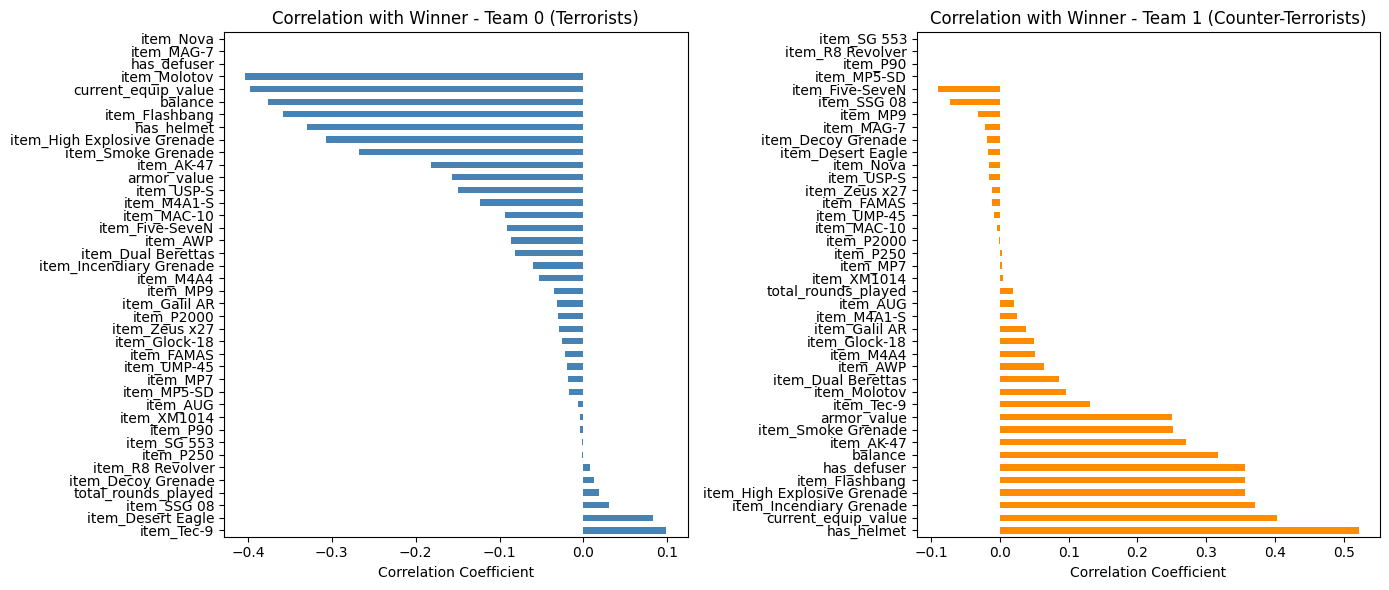

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
if "winner" in corr_team_0.columns:
    corr_winner_team_0.drop("winner").plot(kind="barh", ax=axes[0], color="steelblue")
    axes[0].set_title("Correlation with Winner - Team 0 (Terrorists)")
    axes[0].set_xlabel("Correlation Coefficient")
    corr_winner_team_1.drop("winner").plot(kind="barh", ax=axes[1], color="darkorange")
    axes[1].set_title("Correlation with Winner - Team 1 (Counter-Terrorists)")
    axes[1].set_xlabel("Correlation Coefficient")
else:
    sns.heatmap(corr_team_0, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[0])
    axes[0].set_title("Team 0 Correlations")
    sns.heatmap(corr_team_1, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=axes[1])
    axes[1].set_title("Team 1 Correlations")
plt.tight_layout()
plt.savefig("correlation_winner_by_team.png", dpi=300)
plt.show()

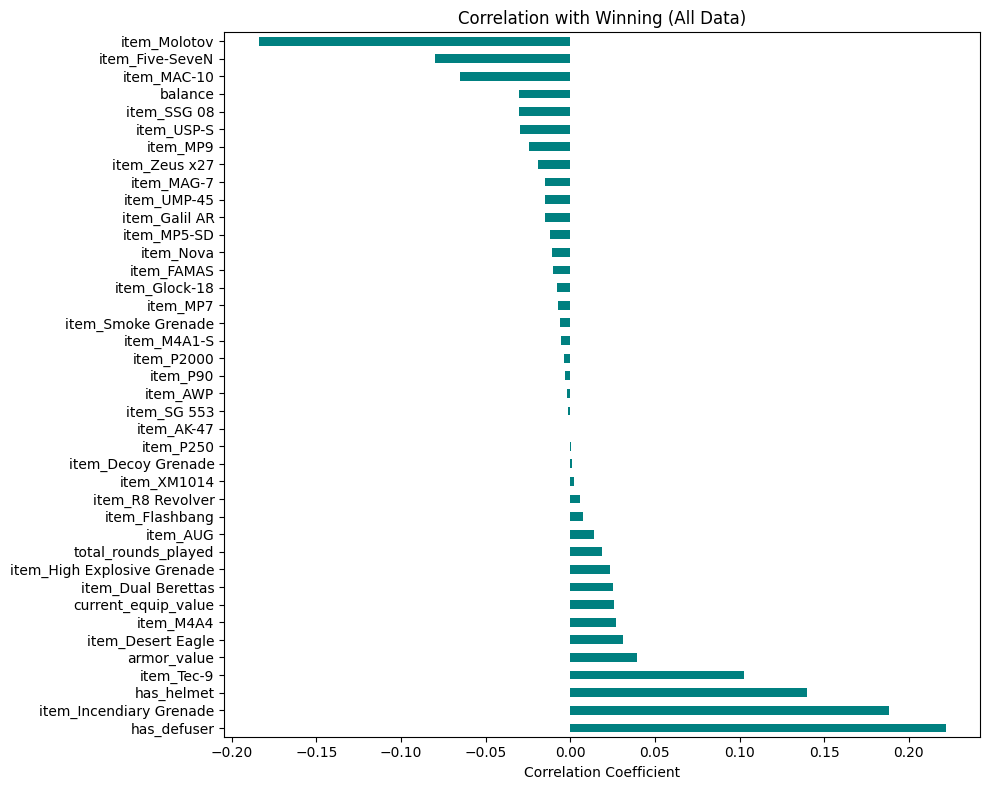

In [16]:
correlation_matrix = df.corr(method="pearson")
if "winner" in correlation_matrix.columns:
    corr_winner_all = correlation_matrix["winner"].sort_values(ascending=False)
    corr_winner_all.to_csv("correlation_winner_all.csv")
    plt.figure(figsize=(10, 8))
    corr_winner_all.drop("winner").plot(kind="barh", color="teal")
    plt.title("Correlation with Winning (All Data)")
    plt.xlabel("Correlation Coefficient")
    plt.tight_layout()
    plt.savefig("correlation_winner_all.png", dpi=300)
    plt.show()
else:
    print("\nCorrelation matrix:")
    print(correlation_matrix)
    plt.figure(figsize=(12, 10))
    sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title("Economic Correlation Matrix (CS2 Major 2025)")
    plt.tight_layout()
    plt.savefig("correlation_matrix_heatmap.png", dpi=300)
    plt.show()

## Supervised Learning Models

In [17]:
df_ml = df_original.copy()
df_ml = df_ml[df_ml["winner"] != "UNKNOWN"]
df_ml = df_ml.dropna(subset=bool_cols)
df_ml = df_ml.drop(columns=["inventory"], errors="ignore")

In [18]:
for col in bool_cols:
    if col in df_ml.columns:
        df_ml[col] = df_ml[col].astype(int)

numeric_cols_ml = ["current_equip_value", "balance", "armor_value"]
for col in numeric_cols_ml:
    if col in df_ml.columns:
        df_ml[col] = pd.to_numeric(df_ml[col], errors="coerce")

df_ml = df_ml.dropna(subset=numeric_cols_ml)
df_ml["winner"] = (df_ml["winner"] == "CT").astype(int)

In [19]:
print(f"\nDataset size: {len(df_ml)} rounds")
print(f"Winner distribution:\n{df_ml['winner'].value_counts()}")
print(f"Class balance: {df_ml['winner'].value_counts(normalize=True).round(3)}")

print(f"Unique team_num values: {df_ml['team_num'].unique()}")
print(f"Total rows: {len(df_ml)}")
print(f"Unique matches: {df_ml['match_id'].nunique()}")


Dataset size: 118180 rounds
Winner distribution:
winner
1    61100
0    57080
Name: count, dtype: int64
Class balance: winner
1    0.517
0    0.483
Name: proportion, dtype: float64
Unique team_num values: [1. 0.]
Total rows: 118180
Unique matches: 578


In [20]:
agg_dict = {"current_equip_value": "mean",
    "balance": "mean",
    "has_helmet": "mean",
    "has_defuser": "mean",
    "winner": "first"}

df_agg = df_ml.groupby(["match_id", "round", "team_num"]).agg(agg_dict).reset_index()
print(f"Aggregated to: {len(df_agg)} team-round records")

Aggregated to: 23598 team-round records


In [21]:
X_list = []
y_list = []
match_ids = []
rounds_processed = 0

for (match_id, round_num), group in df_agg.groupby(["match_id", "round"]):
    if len(group) == 2:
        ct_rows = group[group["team_num"] == 1]
        t_rows = group[group["team_num"] == 0]
        
        if len(ct_rows) > 0 and len(t_rows) > 0:
            ct_data = ct_rows.iloc[0]
            t_data = t_rows.iloc[0]
            rounds_processed += 1
            
            equip_diff = ct_data["current_equip_value"] - t_data["current_equip_value"]
            balance_diff = ct_data["balance"] - t_data["balance"]
            ct_spent = ct_data["balance"] if ct_data["balance"] >= 0 else 0
            t_spent = t_data["balance"] if t_data["balance"] >= 0 else 0
            
            features = {
                "equip_value_diff": equip_diff,
                "balance_diff": balance_diff,
                "ct_helmet": ct_data["has_helmet"],
                "t_helmet": t_data["has_helmet"],
                "ct_defuser": ct_data["has_defuser"],
                "round_num": round_num,
            }
            
            X_list.append(features)
            y_list.append(int(ct_data["winner"]))
            match_ids.append(match_id)

print(f"Rounds with both teams: {rounds_processed}")

Rounds with both teams: 11799


In [22]:
X = pd.DataFrame(X_list)
y = np.array(y_list)
match_ids = np.array(match_ids)

print(f"\nFeature matrix shape: {X.shape}")
feature_names = X.columns.tolist()
print(f"Features: {feature_names}")

print("\nFirst 10 feature rows:")
print(X.head(10))

X_array = X.values


Feature matrix shape: (11799, 6)
Features: ['equip_value_diff', 'balance_diff', 'ct_helmet', 't_helmet', 'ct_defuser', 'round_num']

First 10 feature rows:
   equip_value_diff  balance_diff  ct_helmet  t_helmet  ct_defuser  round_num
0            3840.0       -1620.0        1.0       0.0         0.0        2.0
1            1160.0        1130.0        0.8       1.0         0.2        3.0
2            4890.0        1630.0        1.0       0.0         0.2        4.0
3              90.0       -2600.0        0.4       0.8         0.2        5.0
4           -5530.0       -2700.0        0.0       1.0         0.0        6.0
5            -610.0       -6530.0        0.0       1.0         0.2        7.0
6           -2740.0       -6790.0        0.0       1.0         0.0        8.0
7            -110.0      -10240.0        0.2       1.0         0.2        9.0
8            -110.0      -10750.0        0.6       1.0         0.4       10.0
9             260.0       -5200.0        0.6       1.0         

### MODEL TRAINING AND EVALUATION

#### Model Evaluation

In [23]:
if len(X) == 0:
    print("ERROR: Feature matrix is empty. Cannot train models.")
    print(f"  df_ml shape: {df_ml.shape}")
    print(f"  df_ml columns: {df_ml.columns.tolist()}")
    exit(1)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Neural Network": MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=1000, random_state=42)
}

gkf = GroupKFold(n_splits=5)
results = {}
all_y_true = []
all_y_pred_proba = {model_name: [] for model_name in models.keys()}

for model_name, model in models.items():
    print(f"\n--- {model_name} ---")
    accuracies, precisions, recalls, f1s, aucs = [], [], [], [], []
    fold = 0
    
    for train_idx, test_idx in gkf.split(X_array, y, match_ids):
        fold += 1
        fold_scaler = StandardScaler()
        X_train = fold_scaler.fit_transform(X_array[train_idx])
        X_test = fold_scaler.transform(X_array[test_idx])
        y_train, y_test = y[train_idx], y[test_idx]
        
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_pred_proba = model.predict_proba(X_test)[:, 1]
        
        if fold == gkf.get_n_splits():
            all_y_true = y_test
            all_y_pred_proba[model_name] = y_pred_proba
        
        acc = accuracy_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred, zero_division=0)
        rec = recall_score(y_test, y_pred, zero_division=0)
        f1 = f1_score(y_test, y_pred, zero_division=0)
        roc_auc = roc_auc_score(y_test, y_pred_proba)
        
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1s.append(f1)
        aucs.append(roc_auc)
        
        print(f"Fold {fold}: Acc={acc:.3f}, Prec={prec:.3f}, Rec={rec:.3f}, F1={f1:.3f}, AUC={roc_auc:.3f}")
    
    acc_mean = np.mean(accuracies)
    prec_mean = np.mean(precisions)
    rec_mean = np.mean(recalls)
    f1_mean = np.mean(f1s)
    auc_mean = np.mean(aucs)
    
    results[model_name] = {
        "Accuracy": acc_mean,
        "Precision": prec_mean,
        "Recall": rec_mean,
        "F1": f1_mean,
        "ROC-AUC": auc_mean
    }
    
    print(f"Average - Acc: {acc_mean:.3f} (+/- {np.std(accuracies):.3f})")
    print(f"Average - F1:  {f1_mean:.3f} (+/- {np.std(f1s):.3f})")
    print(f"Average - AUC: {auc_mean:.3f} (+/- {np.std(aucs):.3f})")


--- Logistic Regression ---
Fold 1: Acc=0.888, Prec=0.871, Rec=0.916, F1=0.893, AUC=0.947
Fold 2: Acc=0.878, Prec=0.863, Rec=0.913, F1=0.887, AUC=0.946
Fold 3: Acc=0.885, Prec=0.872, Rec=0.901, F1=0.886, AUC=0.952
Fold 4: Acc=0.882, Prec=0.874, Rec=0.903, F1=0.889, AUC=0.948
Fold 5: Acc=0.896, Prec=0.884, Rec=0.925, F1=0.904, AUC=0.960
Average - Acc: 0.886 (+/- 0.006)
Average - F1:  0.892 (+/- 0.007)
Average - AUC: 0.951 (+/- 0.005)

--- Random Forest ---
Fold 1: Acc=0.883, Prec=0.879, Rec=0.895, F1=0.887, AUC=0.945
Fold 2: Acc=0.873, Prec=0.863, Rec=0.902, F1=0.882, AUC=0.942
Fold 3: Acc=0.880, Prec=0.878, Rec=0.881, F1=0.880, AUC=0.948
Fold 4: Acc=0.883, Prec=0.878, Rec=0.899, F1=0.888, AUC=0.947
Fold 5: Acc=0.895, Prec=0.894, Rec=0.911, F1=0.902, AUC=0.961
Average - Acc: 0.883 (+/- 0.007)
Average - F1:  0.888 (+/- 0.008)
Average - AUC: 0.949 (+/- 0.006)

--- Gradient Boosting ---
Fold 1: Acc=0.885, Prec=0.864, Rec=0.922, F1=0.892, AUC=0.950
Fold 2: Acc=0.877, Prec=0.858, Rec=0.919,

### MODEL COMPARISON

#### Accuracy Comparisons


                     Accuracy  Precision    Recall        F1   ROC-AUC
Logistic Regression  0.885830   0.872966  0.911610  0.891850  0.950646
Random Forest        0.882948   0.878434  0.897603  0.887876  0.948718
Gradient Boosting    0.886170   0.870525  0.915873  0.892581  0.955382
Neural Network       0.880412   0.875303  0.896852  0.885738  0.954276


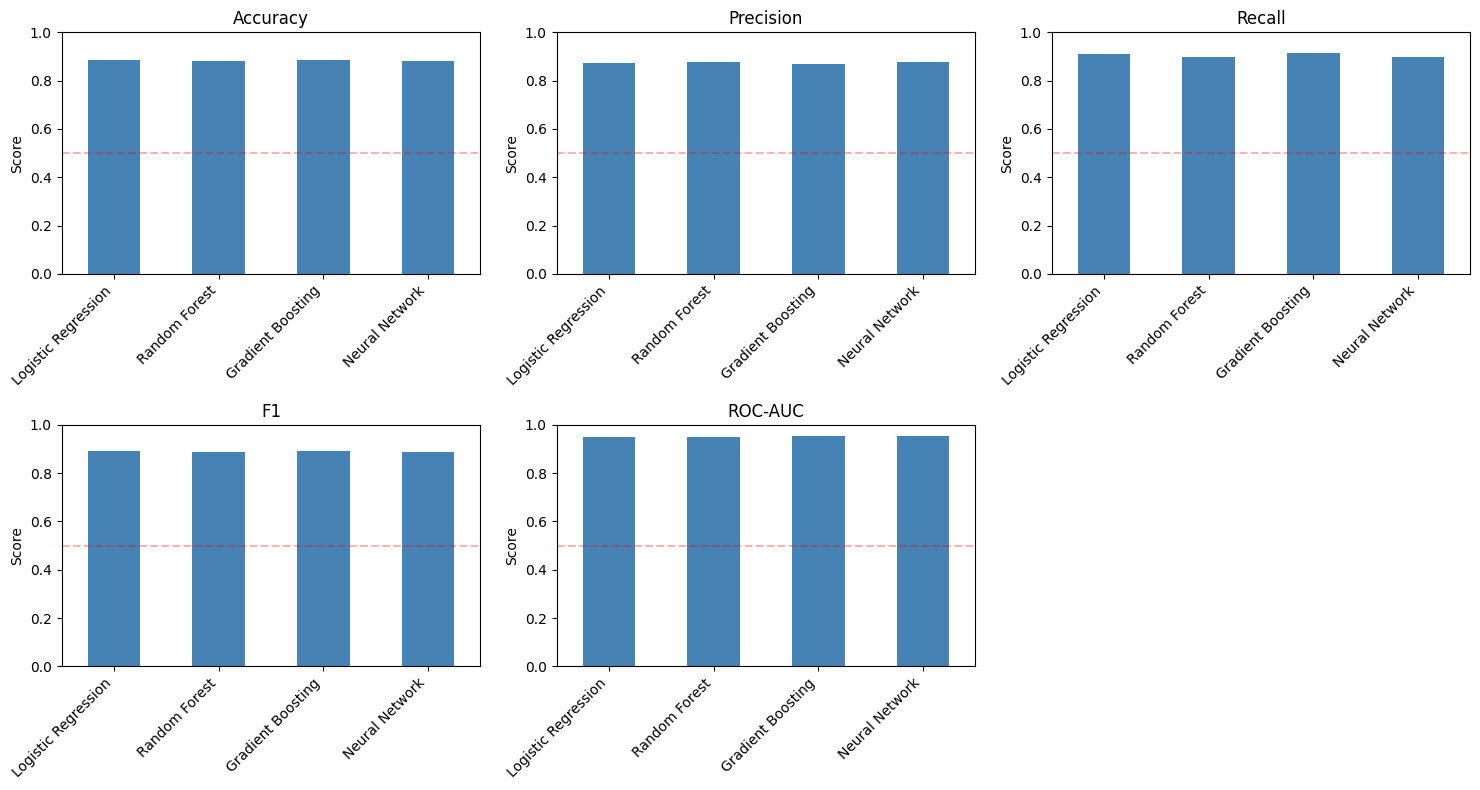

In [24]:
results_df = pd.DataFrame(results).T
print("\n" + results_df.to_string())
results_df.to_csv("model_results.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"]
for idx, metric in enumerate(metrics):
    ax = axes[idx // 3, idx % 3]
    results_df[metric].plot(kind="bar", ax=ax, color="steelblue")
    ax.set_title(metric)
    ax.set_ylabel("Score")
    ax.set_ylim([0, 1])
    ax.axhline(y=0.5, color="r", linestyle="--", alpha=0.3)
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha="right")
axes[1, 2].axis("off")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### Roc Curve Comparisons

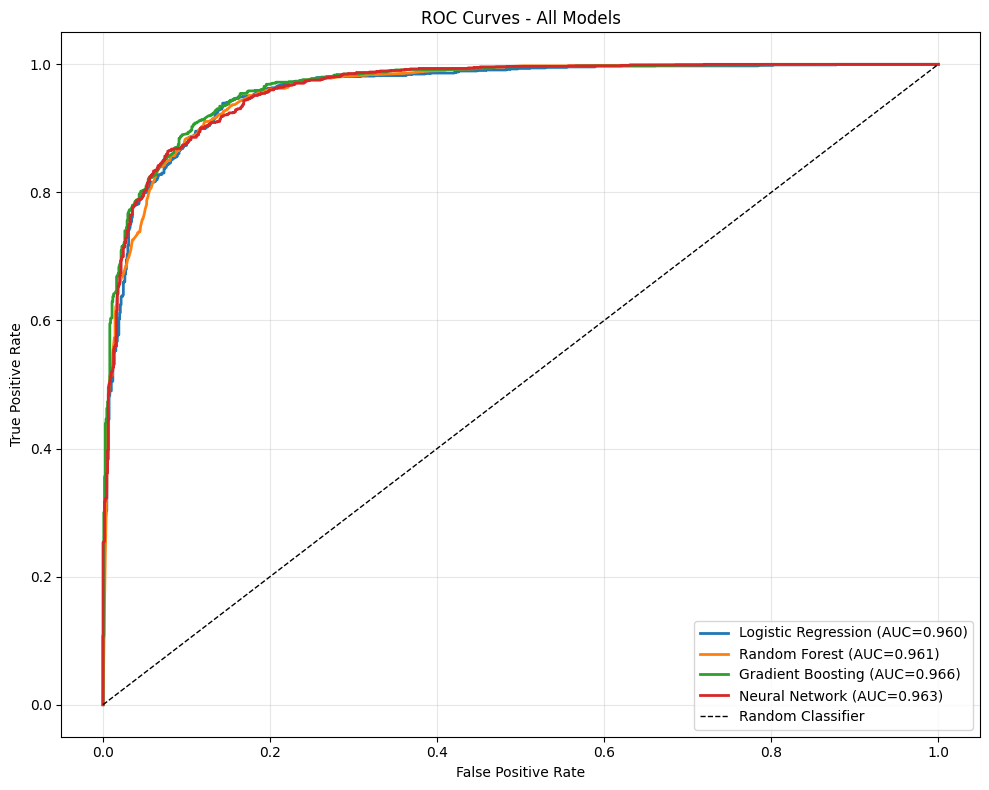

In [25]:
plt.figure(figsize=(10, 8))
for model_name in models.keys():
    if len(all_y_pred_proba[model_name]) > 0:
        fpr, tpr, _ = roc_curve(all_y_true, all_y_pred_proba[model_name])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC={roc_auc:.3f})", linewidth=2)
plt.plot([0, 1], [0, 1], "k--", label="Random Classifier", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curves.png", dpi=300)
plt.show()

#### Feature Important Random Forest

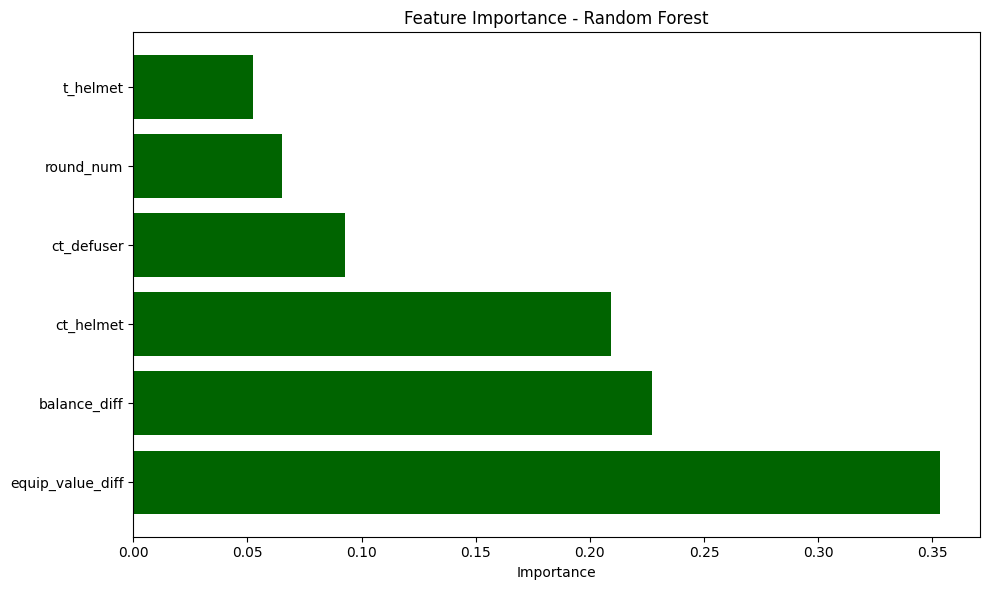


Feature Importance:
         Feature  Importance
equip_value_diff    0.353255
    balance_diff    0.227318
       ct_helmet    0.209443
      ct_defuser    0.092592
       round_num    0.065130
        t_helmet    0.052261


In [26]:
final_scaler = StandardScaler().fit(X_array)
X_full_scaled = final_scaler.transform(X_array)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_full_scaled, y)

fi_data = {
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
}
feature_importance = pd.DataFrame(fi_data).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["Feature"], feature_importance["Importance"], color="darkgreen")
plt.xlabel("Importance")
plt.title("Feature Importance - Random Forest")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=300)
plt.show()

print("\nFeature Importance:")
print(feature_importance.to_string(index=False))
feature_importance.to_csv("feature_importance.csv", index=False)

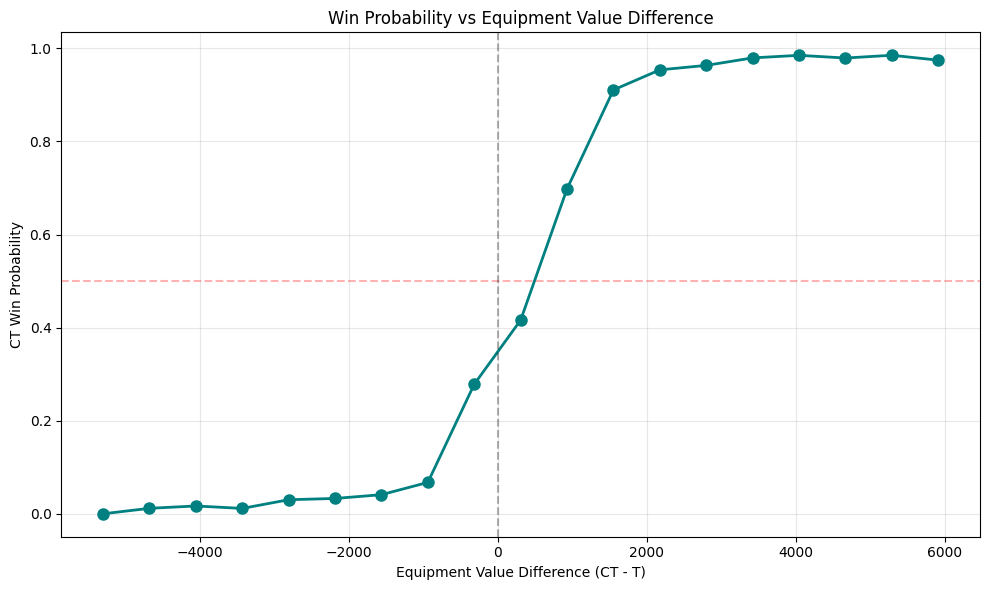

In [27]:
plt.figure(figsize=(10, 6))
bins = np.linspace(X["equip_value_diff"].min(), X["equip_value_diff"].max(), 20)
X_binned = pd.cut(X["equip_value_diff"], bins=bins)

prob_data = {
    "equip_diff": X["equip_value_diff"],
    "winner": y}

win_prob_by_bin = pd.DataFrame(prob_data).groupby(pd.cut(X["equip_value_diff"], bins=bins), observed=False)["winner"].mean()

bin_centers = [(bins[i] + bins[i+1]) / 2 for i in range(len(bins)-1)]
plt.plot(bin_centers, win_prob_by_bin.values, "o-", linewidth=2, markersize=8, color="teal")
plt.xlabel("Equipment Value Difference (CT - T)")
plt.ylabel("CT Win Probability")
plt.title("Win Probability vs Equipment Value Difference")
plt.axhline(y=0.5, color="r", linestyle="--", alpha=0.3)
plt.axvline(x=0, color="k", linestyle="--", alpha=0.3)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("win_probability_vs_equip.png", dpi=300)
plt.show()